# ISO 20414:2020 — Test 10: Congestion in front of a flight of stairs

150 occupants in an 8 m x 5 m room funnelling into a 2 m corridor that leads to a flight of stairs (ISO 20414:2020 Table 11). JuPedSim has no native stairs, so the stair is modelled as the upper segment of the corridor carrying a `speed_factor = 0.5` zone (agents move at half speed on it, as in Tests 3 and 12). Two constrictions result: the 8 m -> 2 m room->neck entrance, and the slower stair. Per ISO the expected result is congestion at the room exit, a steady flow along the corridor, and a second build-up at the base of the stairs.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 07 July 2026, 19:02 CEST


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from jupedsim_scenarios import load_scenario, run_scenario

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load and run

In [4]:
SCENARIO_ZIP = Path("scenario_files") / "Iso-10-congestion.zip"
scenario = load_scenario(str(SCENARIO_ZIP))
# The corridor runs y=5..20; model its upper half (y=14..20) as the stair by
# adding a speed_factor=0.5 zone, so the stair base sits at y=14.
STAIR_BASE_Y = 14.0
scenario.add_zone([(3, STAIR_BASE_Y), (5, STAIR_BASE_Y), (5, 20), (3, 20)],
                  key="jps-zones_stair", speed_factor=0.5)
print(scenario.summary())
result = run_scenario(scenario, seed=42)
df = result.trajectory_dataframe()

Scenario: /Users/chraibi/workspace/PedestrianDynamics/jupedsim-web-community/standards/iso/scenario_files/Iso-10-congestion.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      400s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         1
  Journeys:      1
  Agents:        ~150
  Journey elems: 2
  Route:         1 distribution, 0 checkpoint, 1 exit
  Sequence:      jps-distributions_0 -> jps-exits_0
    jps-distributions_0: 150 agents


## Density at the room->neck entrance, mid-corridor, and stair base

The stair base sits at y = 14. We track density in three 2 m-wide bands: the room->neck entrance (y = 4.5..5.5), a mid-corridor free-flow reference (y = 8..10), and the foot of the stair (y = 13..14).

In [5]:
def rho(sub, x0, x1, y0, y1):
    n = len(sub[(sub.x >= x0) & (sub.x <= x1) & (sub.y >= y0) & (sub.y <= y1)])
    return n / ((x1 - x0) * (y1 - y0))
rows = []
for frame, sub in df.groupby('frame'):
    rows.append({'time_s': frame / result.frame_rate,
                 'rho_room_exit': rho(sub, 3.0, 5.0, 4.5, 5.5),
                 'rho_corridor': rho(sub, 3.0, 5.0, 8.0, 10.0),
                 'rho_stair_base': rho(sub, 3.0, 5.0, 13.0, 14.0)})
density = pd.DataFrame(rows)
density.describe()

,time_s,rho_room_exit,rho_corridor,rho_stair_base
count,842.000000,842.000000,842.000000,842.000000
mean,42.050000,2.330166,1.574228,1.992280
std,24.320876,2.029132,1.146123,1.255996
min,0.000000,0.000000,0.000000,0.000000
25%,21.025000,0.000000,0.000000,1.000000
50%,42.050000,3.000000,2.000000,2.500000
75%,63.075000,4.000000,2.500000,3.000000
max,84.100000,6.000000,3.250000,5.000000


## Plot densities over time

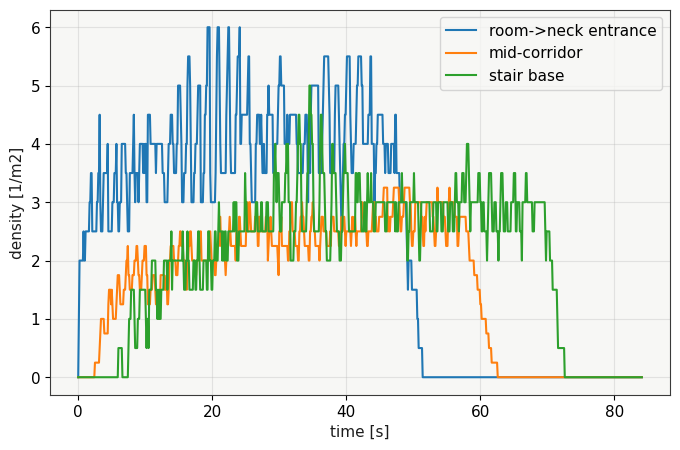

In [6]:
fig, ax = plt.subplots()
ax.plot(density.time_s, density.rho_room_exit, label='room->neck entrance')
ax.plot(density.time_s, density.rho_corridor, label='mid-corridor')
ax.plot(density.time_s, density.rho_stair_base, label='stair base')
ax.set_xlabel('time [s]'); ax.set_ylabel('density [1/m2]'); ax.legend()
plt.show()

## Acceptance

Two constrictions drive congestion: the 8 m room funnelling into the 2 m neck, and the slower stair. Peak density must build at the room->neck entrance **and** at the base of the stairs, both exceeding the steady mid-corridor density — the two congestion points ISO Test 10 expects.

In [7]:
peak = density[['rho_room_exit', 'rho_corridor', 'rho_stair_base']].max()
print(peak)
print(f"room->neck entrance peak = {peak['rho_room_exit']:.2f} p/m2, "
      f"mid-corridor = {peak['rho_corridor']:.2f} p/m2, stair base = {peak['rho_stair_base']:.2f} p/m2")
assert peak['rho_room_exit'] > peak['rho_corridor'], peak
assert peak['rho_stair_base'] > peak['rho_corridor'], peak
result.cleanup()

rho_room_exit     6.00
rho_corridor      3.25
rho_stair_base    5.00
dtype: float64
room->neck entrance peak = 6.00 p/m2, mid-corridor = 3.25 p/m2, stair base = 5.00 p/m2


1